In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends.csv
/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends_updated.csv


In [46]:
df=pd.read_csv("/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends_updated.csv")

In [47]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [48]:
df["customer_tier"]=df["Purchase Amount (USD)"].apply(lambda x: "Premium"if x>80 else "Regular")

In [49]:
df["customer_tier"]

0       Regular
1       Regular
2       Regular
3       Premium
4       Regular
         ...   
3895    Regular
3896    Regular
3897    Regular
3898    Regular
3899    Premium
Name: customer_tier, Length: 3900, dtype: object

In [50]:
df["age_group"]=df["Age"].apply(lambda x: "Young"if x>30 else "Adult")

In [51]:
df["age_group"]

0       Young
1       Adult
2       Young
3       Adult
4       Young
        ...  
3895    Young
3896    Young
3897    Young
3898    Young
3899    Young
Name: age_group, Length: 3900, dtype: object

In [52]:
df["Rating"]=df["Review Rating"].apply(lambda x: "Good" if x>4 else "Average")

In [53]:
df["Rating"]

0       Average
1       Average
2       Average
3       Average
4       Average
         ...   
3895       Good
3896       Good
3897    Average
3898    Average
3899    Average
Name: Rating, Length: 3900, dtype: object

In [54]:
df["discounted_price"] = df["Purchase Amount (USD)"] * 0.9
df["discounted_price"]

0       47.7
1       57.6
2       65.7
3       81.0
4       44.1
        ... 
3895    25.2
3896    44.1
3897    29.7
3898    69.3
3899    72.9
Name: discounted_price, Length: 3900, dtype: float64

In [55]:
df["final price"]=df["Purchase Amount (USD)"]*1.18
df["final price"]

0        62.54
1        75.52
2        86.14
3       106.20
4        57.82
         ...  
3895     33.04
3896     57.82
3897     38.94
3898     90.86
3899     95.58
Name: final price, Length: 3900, dtype: float64

In [56]:
df["Profit"]=df["final price"]-df["discounted_price"]
df["Profit"]

0       14.84
1       17.92
2       20.44
3       25.20
4       13.72
        ...  
3895     7.84
3896    13.72
3897     9.24
3898    21.56
3899    22.68
Name: Profit, Length: 3900, dtype: float64

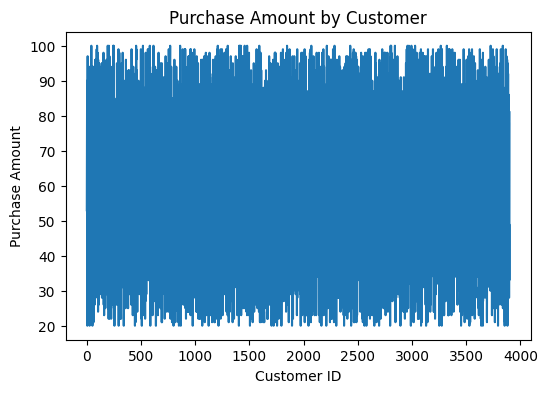

In [57]:
plt.figure(figsize=(6,4))

plt.plot(df["Customer ID"], df["Purchase Amount (USD)"])

plt.title("Purchase Amount by Customer")
plt.xlabel("Customer ID")
plt.ylabel("Purchase Amount")

plt.show()

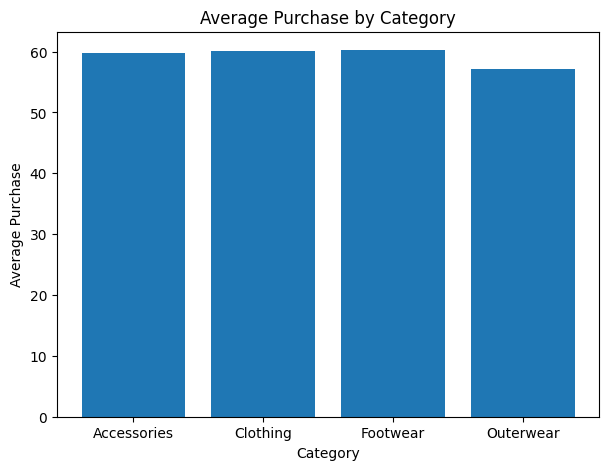

In [59]:
category_sales = df.groupby("Category")["Purchase Amount (USD)"].mean()

plt.figure(figsize=(7,5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Average Purchase by Category")
plt.xlabel("Category")
plt.ylabel("Average Purchase")

plt.show()

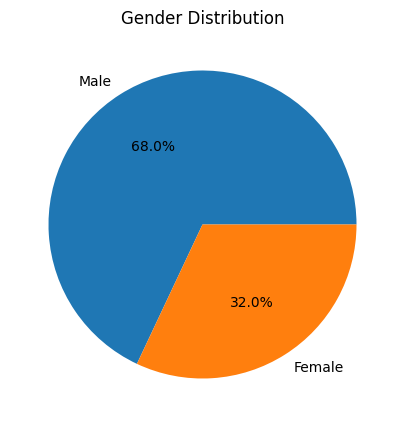

In [61]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()


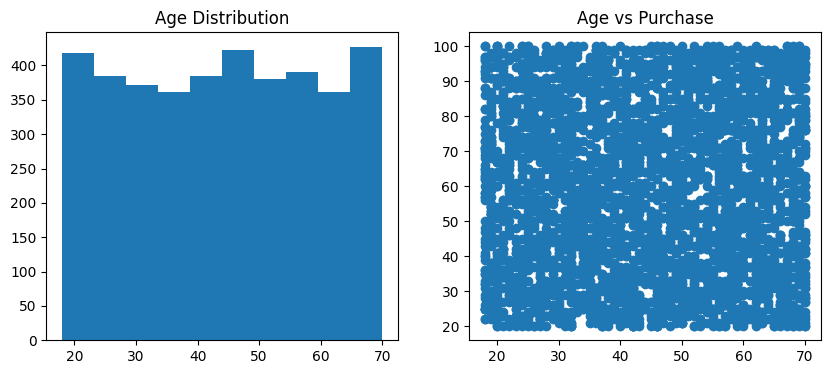

In [62]:
plt.figure(figsize=(10,4))

# Plot 1
plt.subplot(1,2,1)

plt.hist(df["Age"])

plt.title("Age Distribution")

# Plot 2
plt.subplot(1,2,2)

plt.scatter(
    df["Age"],
    df["Purchase Amount (USD)"]
)

plt.title("Age vs Purchase")

plt.show()